# DISCO vs Baselines in S-mode

Benchmark of DISCO against baseline methods when both are evaluated with secure (S-mode) counterfactuals.

This notebook reuses the synthetic scenario bundle and compares how well each method reproduces the oracle (population simplex) treatment-effect curve across many interventions and query points.

In [3]:
# Add repository root to the Python path
import sys
import os
sys.path.append(os.path.abspath('../..'))


In [4]:
SEED = 42

number_of_devices = 10 # total devices in the scenario
number_of_deployed_devices = 10 # out of which we train models

number_of_probe_samples = 1200
number_of_probe_to_use = 1200

number_of_features = 20
number_of_training_samples_per_device = 8000
number_of_queries = 80

target_device_index = 0
target_effect_scale = 0.0

pregrid_thetas = [0.0, 0.25, 0.5, 0.75, 1.0]
postgrid_thetas = [1.2, 1.35, 1.5, 1.65, 1.8, 2.0]

num_anchors_for_matching = 12
anchor_kernel_bandwidth = 0.2
ridge_regularization_lambda = 0.01

counterfactual_mode = 's'  # 's' (secure) and 'p' (proxy) for the DISCO run
base_offset_std = 0.0 # stddev for device base offsets (heterogeneity)
peer_effect_std = 0.0 # stddev of peer treatment strengths around the target’s
generator_noise_std = 0.02 # observation noise injected by the generator

intervention_config_yaml = "experiments/configs/tabular_interventions.yaml"

scenario_output_dir = "experiments/results/synth_run"
scenario_path = os.path.join(scenario_output_dir, "scenario.npz")
device_output_dir = "experiments/synth_devices"
probes_output_dir = os.path.join(scenario_output_dir, "probes")
explain_output_dir = os.path.join(scenario_output_dir, "explain")


print(f"""
This notebook evaluates DISCO and simple baselines on the synthetic scenario generated via the CLI.

Run the scenario commands (synth, train-devices --dataset scenario, probe --dataset scenario) before executing the cells below.      

# 1 Generate a scenario (with heterogeneity + noise):
    python -m disco.cli.main synth --p {number_of_features} --N {number_of_devices} --m {number_of_probe_samples} --alpha {target_effect_scale} --theta0 "{pregrid_thetas}" --theta "{postgrid_thetas}" --K {num_anchors_for_matching} --tau {anchor_kernel_bandwidth} --lam {ridge_regularization_lambda} --mode {counterfactual_mode} --base-jitter {base_offset_std} --peer-alpha-std {peer_effect_std} --noise-std {generator_noise_std} --out {scenario_output_dir} --seed {SEED}

# 2 Train heterogeneous models on scenario data:
    python -m disco.cli.main train-devices --dataset scenario --scenario {scenario_path} --samples {number_of_training_samples_per_device} --N {number_of_deployed_devices} --out {device_output_dir} --seed {SEED}
""")


This notebook evaluates DISCO and simple baselines on the synthetic scenario generated via the CLI.

Run the scenario commands (synth, train-devices --dataset scenario, probe --dataset scenario) before executing the cells below.      

# 1 Generate a scenario (with heterogeneity + noise):
    python -m disco.cli.main synth --p 20 --N 10 --m 1200 --alpha 0.0 --theta0 "[0.0, 0.25, 0.5, 0.75, 1.0]" --theta "[1.2, 1.35, 1.5, 1.65, 1.8, 2.0]" --K 12 --tau 0.2 --lam 0.01 --mode s --base-jitter 0.0 --peer-alpha-std 0.0 --noise-std 0.02 --out experiments/results/synth_run --seed 42

# 2 Train heterogeneous models on scenario data:
    python -m disco.cli.main train-devices --dataset scenario --scenario experiments/results/synth_run\scenario.npz --samples 8000 --N 10 --out experiments/synth_devices --seed 42



In [5]:
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple
import json
import math

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from disco.synth.generator import SyntheticScenario
from disco.explain.disco_algorithm import DiscoRunner
from disco.explain.baselines import BaselineRunner
from disco.explain.te_curve import Explainer
from disco.interventions.tabular import FeatureAdd, ClampedShift
from disco.interventions.grids import Grids
from disco.cli.main import compute_probe_trajectories, load_devices
from disco.matching.weights import WeightSolver
from disco.explain.pier import compute_pier_truth, compute_pier_metrics


In [6]:
# Helper utilities
def load_scenario_bundle(scenario_dir: Path):
    """Load scenario assets plus any precomputed probe trajectories."""
    scenario = SyntheticScenario.load(scenario_dir / 'scenario.npz')
    trajectories: Dict[Tuple[str, str], np.ndarray] = {}
    sample_rows = None
    probes_dir = scenario_dir / 'probes'
    if probes_dir.exists():
        for npy_path in probes_dir.glob('*.npy'):
            if npy_path.name == 'X_probe.npy':
                continue
            parts = npy_path.stem.split('_', 2)
            if len(parts) < 3:
                continue
            device_id = f"{parts[0]}_{parts[1]}"
            interv_name = '_'.join(parts[2:])
            data = np.load(npy_path)
            trajectories[(device_id, interv_name)] = data
            if sample_rows is None:
                sample_rows = data.shape[0]
    X_probe = scenario.X_probe
    if sample_rows is not None and sample_rows < len(X_probe):
        X_probe = X_probe[:sample_rows]
    return scenario, trajectories, X_probe


def summarise_feature_bounds(X: np.ndarray) -> Dict[int, Tuple[float, float]]:
    """Empirical 5th/95th percentiles per feature for clamping."""
    bounds = {}
    for idx in range(X.shape[1]):
        lower, upper = np.percentile(X[:, idx], [5, 95])
        bounds[idx] = (float(lower), float(upper))
    return bounds


def sample_random_interventions(
    n_interventions: int,
    X_probe: np.ndarray,
    theta_post: np.ndarray,
    rng: np.random.Generator,
) -> List:
    """Generate a diverse intervention set."""
    bounds = summarise_feature_bounds(X_probe)
    interventions = []
    used_names = set()
    feature_dim = X_probe.shape[1]
    for idx in range(n_interventions):
        kind = rng.choice(['feature_add', 'clamped_shift'])
        if kind == 'feature_add':
            feat_idx = int(rng.integers(0, feature_dim))
            delta_max = float(theta_post[-1])
            name = f"add_f{feat_idx}_{idx:03d}"
            intervention = FeatureAdd(
                feat_idx=feat_idx,
                delta_max=delta_max,
                clamp=(-3.0, 3.0),
                name=name,
            )
        else:
            feat_idx = int(rng.integers(0, feature_dim))
            lower, upper = bounds.get(feat_idx, (-3.0, 3.0))
            if not np.isfinite(lower) or not np.isfinite(upper) or abs(upper - lower) < 1e-3:
                lower, upper = -3.0, 3.0
            shift_max = float(rng.uniform(0.4, 1.0))
            name = f"clamped_f{feat_idx}_{idx:03d}"
            intervention = ClampedShift(
                feat_idx=feat_idx,
                shift_max=shift_max,
                lower=lower,
                upper=upper,
                name=name,
            )
        if intervention.name in used_names:
            intervention.name = f"{intervention.name}_{idx}"
        used_names.add(intervention.name)
        interventions.append(intervention)
    return interventions


def compute_curve_metrics(tau_hat: np.ndarray, tau_true: np.ndarray, theta: np.ndarray) -> Dict[str, float]:
    diff = tau_hat - tau_true
    abs_diff = np.abs(diff)
    metrics = {
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'mae': float(abs_diff.mean()),
        'max_abs': float(abs_diff.max()),
        'auc_abs_diff': float(np.trapz(abs_diff, theta)),
    }
    return metrics


def to_serialisable(meta: Dict) -> Dict:
    if meta is None:
        return {}
    serialised = {}
    for key, value in meta.items():
        if isinstance(value, np.generic):
            serialised[key] = value.item()
        elif isinstance(value, np.ndarray):
            serialised[key] = value.tolist()
        else:
            serialised[key] = value
    return serialised


In [7]:
# Load scenario assets and configure experiment
SCENARIO_DIR = Path('..').resolve() / 'results' / 'synth_run'
MODEL_DIR = Path('..').resolve() / 'synth_devices'

scenario, scenario_trajs, scenario_X_probe = load_scenario_bundle(SCENARIO_DIR)
model_devices = load_devices(str(MODEL_DIR))

print(f"Oracle devices: {len(scenario.devices)}")
print(f"Model devices: {len(model_devices)}")

grids = Grids(theta0=scenario.theta0, theta=scenario.theta)
theta_post = grids.theta

target_idx = 0
target_device = model_devices[target_idx]
target_class = 0 if getattr(target_device, 'task', 'regression') != 'classification' else 1

rng = np.random.default_rng(42)
N_INTERVENTIONS = 10
N_QUERIES = 50

interventions = sample_random_interventions(N_INTERVENTIONS, scenario_X_probe, theta_post, rng)
print(f"Sampled {len(interventions)} interventions. First five: {[interv.name for interv in interventions[:5]]}")


Oracle devices: 10
Model devices: 10
Sampled 10 interventions. First five: ['add_f15_000', 'clamped_f8_001', 'add_f13_002', 'add_f1_003', 'clamped_f19_004']


In [8]:
# Pre-compute probe trajectories for the intervention set
probe_trajectories_model = compute_probe_trajectories(
    devices=model_devices,
    X_probe=scenario_X_probe,
    interventions=interventions,
    theta0=grids.theta0,
    dp_noise_std=0.0,
    seed=0,
    target_class=target_class,
)
probe_trajectories_oracle = compute_probe_trajectories(
    devices=scenario.devices,
    X_probe=scenario_X_probe,
    interventions=interventions,
    theta0=grids.theta0,
    dp_noise_std=0.0,
    seed=0,
    target_class=target_class,
)
print(f"Computed {len(probe_trajectories_model)} model trajectory tensors and {len(probe_trajectories_oracle)} oracle tensors")

trajectories_model_by_intervention: Dict[str, Dict[Tuple[str, str], np.ndarray]] = {}
trajectories_oracle_by_intervention: Dict[str, Dict[Tuple[str, str], np.ndarray]] = {}
for intervention in interventions:
    name = intervention.name
    trajectories_model_by_intervention[name] = {
        key: value for key, value in probe_trajectories_model.items() if key[1] == name
    }
    trajectories_oracle_by_intervention[name] = {
        key: value for key, value in probe_trajectories_oracle.items() if key[1] == name
    }

if N_QUERIES > len(scenario_X_probe):
    raise ValueError(f"Requested {N_QUERIES} queries but only {len(scenario_X_probe)} probes available")
query_indices = rng.choice(len(scenario_X_probe), size=N_QUERIES, replace=False)
query_points = scenario_X_probe[query_indices]
print(f"Selected {len(query_points)} query points from the probe pool")


Computed 100 model trajectory tensors and 100 oracle tensors
Selected 50 query points from the probe pool


In [9]:
# Instantiate runners
disco_runner = DiscoRunner(mode='s', explainer=Explainer(compute_flip=False), anchor_space="response")
baseline_runner = BaselineRunner(explainer=Explainer(compute_flip=False))
global_weight_solver = WeightSolver(method='projected_grad', max_iter=2000)


In [10]:
# Benchmark loop: DISCO vs baselines for every (intervention, query)
theta_vec = grids.theta
records = []
curve_bank = defaultdict(lambda: defaultdict(list))
failure_log = defaultdict(list)

for intervention in tqdm(interventions, desc='Interventions'):
    traj_slice_model = trajectories_model_by_intervention[intervention.name]
    traj_slice_oracle = trajectories_oracle_by_intervention[intervention.name]
    for local_idx, probe_idx in enumerate(query_indices):
        x_star = scenario_X_probe[probe_idx:probe_idx + 1]

        try:
            disco_output = disco_runner.run(
                devices=model_devices,
                target_idx=target_idx,
                x_star=x_star,
                X_probe=scenario_X_probe,
                trajectories=traj_slice_model,
                grids=grids,
                intervention=intervention,
                target_class=target_class,
                mode='s',
                lam=0.01,
            )
        except Exception as exc:
            failure_log['disco'].append((intervention.name, int(probe_idx), str(exc)))
            continue

        disco_te = disco_output.te_output
        disco_tau = disco_te.tau
        disco_diag = disco_output.diagnostics
        disco_meta = {key: disco_diag.get(key) for key in ['eps_pre', 'anchor_radius', 'proxy_bias', 'weight_sparsity', 'n_effective_peers']}
        anchor_sel = disco_diag.get('anchor_selection')

        oracle_output = baseline_runner.baseline_oracle_ground_truth(
            devices=model_devices,
            trajectories=traj_slice_model,
            theta0=grids.theta0,
            x_star=x_star,
            grids=grids,
            intervention=intervention,
            target_idx=target_idx,
            target_class=target_class,
            oracle_devices=scenario.devices,
            oracle_trajectories=traj_slice_oracle,
            oracle_theta0=grids.theta0,
        )
        tau_true = oracle_output.tau

        method_curves = {
            'disco': (disco_tau, disco_meta),
            'oracle_w': (tau_true, oracle_output.meta),
        }

        try:
            avg_output = baseline_runner.baseline_avg(
                devices=model_devices,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_idx=target_idx,
                target_class=target_class,
            )
            method_curves['avg'] = (avg_output.tau, avg_output.meta)
        except Exception as exc:
            failure_log['avg'].append((intervention.name, int(probe_idx), str(exc)))

        if anchor_sel is not None:
            try:
                topk_output = baseline_runner.baseline_topk_avg(
                    devices=model_devices,
                    trajectories=traj_slice_model,
                    anchor_sel=anchor_sel,
                    theta0=grids.theta0,
                    x_star=x_star,
                    grids=grids,
                    intervention=intervention,
                    target_idx=target_idx,
                    Kp=5,
                    target_class=target_class,
                )
                method_curves['topk'] = (topk_output.tau, topk_output.meta)
            except Exception as exc:
                failure_log['topk'].append((intervention.name, int(probe_idx), str(exc)))

            try:
                ridge_output = baseline_runner.baseline_unconstrained_ridge(
                    devices=model_devices,
                    trajectories=traj_slice_model,
                    anchor_sel=anchor_sel,
                    theta0=grids.theta0,
                    x_star=x_star,
                    grids=grids,
                    intervention=intervention,
                    target_idx=target_idx,
                    lam=0.01,
                    target_class=target_class,
                )
                method_curves['unconstrained_ridge'] = (ridge_output.tau, ridge_output.meta)
            except Exception as exc:
                failure_log['unconstrained_ridge'].append((intervention.name, int(probe_idx), str(exc)))

        try:
            glob_output = baseline_runner.baseline_glob_matching(
                devices=model_devices,
                trajectories=traj_slice_model,
                theta0=grids.theta0,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_idx=target_idx,
                weight_solver=global_weight_solver,
                target_class=target_class,
            )
            method_curves['glob_matching'] = (glob_output.tau, glob_output.meta)
        except Exception as exc:
            failure_log['glob_matching'].append((intervention.name, int(probe_idx), str(exc)))

        try:
            cone_output = baseline_runner.baseline_cone_relaxed_matching(
                devices=model_devices,
                trajectories=traj_slice_model,
                theta0=grids.theta0,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_idx=target_idx,
                lam=0.01,
                target_class=target_class,
            )
            method_curves['cone_relaxed'] = (cone_output.tau, cone_output.meta)
        except Exception as exc:
            failure_log['cone_relaxed'].append((intervention.name, int(probe_idx), str(exc)))

        try:
            lp_output = baseline_runner.baseline_local_perturbation(
                device_t=target_device,
                x_star=x_star,
                grids=grids,
                intervention=intervention,
                target_class=target_class,
            )
            method_curves['local_perturbation'] = (lp_output.tau, lp_output.meta)
        except Exception as exc:
            failure_log['local_perturbation'].append((intervention.name, int(probe_idx), str(exc)))

        tau_true_auc = float(np.trapz(np.abs(tau_true), theta_vec))
        tau_true_energy = float(np.sqrt(np.mean(tau_true ** 2)))
        # PIER truth from scenario and oracle weights
        w_star = np.array(oracle_output.meta['weights'])
        pier_true = compute_pier_truth(scenario, w_star, x_star, theta_vec, intervention)
        theta_break = None

        for method_name, (tau_hat, meta) in method_curves.items():
            metrics = compute_curve_metrics(tau_hat, tau_true, theta_vec)
            pier_metrics = compute_pier_metrics(tau_hat, pier_true, theta_vec, theta_break)
            record = {
                'method': method_name,
                'intervention': intervention.name,
                'query_index': int(local_idx),
                'probe_index': int(probe_idx),
                'tau_true_auc': tau_true_auc,
                'tau_true_energy': tau_true_energy,
            }
            record.update(metrics)
            record.update(pier_metrics)
            if method_name == 'disco':
                for key, value in disco_meta.items():
                    record[f'disco_{key}'] = value
            record['meta'] = json.dumps(to_serialisable(meta))
            curve_bank[intervention.name][method_name].append(np.array(tau_hat, dtype=float))
            records.append(record)

failure_summary = {name: len(entries) for name, entries in failure_log.items() if entries}
print('Failure summary:', failure_summary if failure_summary else 'None')

results_df = pd.DataFrame.from_records(records)
print(f"Collected {len(results_df)} method evaluations")


Interventions:   0%|          | 0/10 [00:00<?, ?it/s]

Failure summary: None
Collected 4000 method evaluations


In [11]:
pd.set_option('display.max_columns', None)

# Aggregate metrics with standard errors
metric_cols = ['rmse', 'mae', 'max_abs', 'auc_abs_diff', 'pier_nrmse', 'pier_auc_abs_diff', 'pier_corr', 'onset_abs_err']
summary = (
    results_df
    .groupby('method')[metric_cols]
    .agg(['mean', 'std', 'count'])
)

for metric in metric_cols:
    summary[(metric, 'sem')] = summary[(metric, 'std')] / np.sqrt(summary[(metric, 'count')].clip(lower=1))

summary = summary.sort_values(('rmse', 'mean'))
summary.columns = ['{}_{}'.format(col[0], col[1]) for col in summary.columns]
summary = summary.reset_index()
summary


,method,rmse_mean,rmse_std,rmse_count,mae_mean,mae_std,mae_count,max_abs_mean,max_abs_std,max_abs_count,auc_abs_diff_mean,auc_abs_diff_std,auc_abs_diff_count,pier_nrmse_mean,pier_nrmse_std,pier_nrmse_count,pier_auc_abs_diff_mean,pier_auc_abs_diff_std,pier_auc_abs_diff_count,pier_corr_mean,pier_corr_std,pier_corr_count,onset_abs_err_mean,onset_abs_err_std,onset_abs_err_count,rmse_sem,mae_sem,max_abs_sem,auc_abs_diff_sem,pier_nrmse_sem,pier_auc_abs_diff_sem,pier_corr_sem,onset_abs_err_sem
0,oracle_w,0.000000,0.000000,500,0.000000,0.000000,500,0.000000,0.000000,500,0.000000,0.000000,500,5.088351e-15,9.998370e-15,500,3.807388e-17,3.844135e-17,500,1.000000,1.074266e-16,205,NaN,NaN,0,0.000000,0.000000,0.000000,0.000000,4.471407e-16,1.719149e-18,7.502999e-18,NaN
1,unconstrained_ridge,0.032272,0.026261,500,0.031814,0.026250,500,0.035426,0.028203,500,0.025431,0.021050,500,2.737004e+00,6.949238e+00,500,2.543138e-02,2.105044e-02,500,0.025733,8.441621e-01,205,NaN,NaN,0,0.001174,0.001174,0.001261,0.000941,3.107794e-01,9.414044e-04,5.895884e-02,NaN
2,disco,0.032544,0.025791,500,0.032062,0.025764,500,0.035730,0.027830,500,0.025628,0.020671,500,3.041045e+00,9.355818e+00,500,2.562836e-02,2.067138e-02,500,0.004833,8.576370e-01,205,NaN,NaN,0,0.001153,0.001152,0.001245,0.000924,4.184049e-01,9.244521e-04,5.989997e-02,NaN
3,topk,0.033106,0.026270,500,0.032605,0.026220,500,0.036476,0.028387,500,0.026069,0.021030,500,3.466149e+00,1.487808e+01,500,2.606857e-02,2.103039e-02,500,-0.043432,8.518267e-01,205,NaN,NaN,0,0.001175,0.001173,0.001269,0.000941,6.653678e-01,9.405078e-04,5.949416e-02,NaN
4,glob_matching,0.034095,0.027186,500,0.033612,0.027172,500,0.037288,0.029100,500,0.026870,0.021798,500,3.243868e+00,1.032365e+01,500,2.686981e-02,2.179798e-02,500,0.018080,8.572860e-01,205,NaN,NaN,0,0.001216,0.001215,0.001301,0.000975,4.616876e-01,9.748352e-04,5.987545e-02,NaN
5,cone_relaxed,0.034144,0.027309,500,0.033661,0.027303,500,0.037342,0.029182,500,0.026908,0.021903,500,3.195724e+00,9.767026e+00,500,2.690763e-02,2.190275e-02,500,0.018580,8.567862e-01,205,NaN,NaN,0,0.001221,0.001221,0.001305,0.000980,4.367947e-01,9.795205e-04,5.984055e-02,NaN
6,avg,0.034271,0.027484,500,0.033792,0.027486,500,0.037486,0.029307,500,0.027010,0.022050,500,3.141047e+00,9.156606e+00,500,2.700984e-02,2.205017e-02,500,0.018106,8.578811e-01,205,NaN,NaN,0,0.001229,0.001229,0.001311,0.000986,4.094959e-01,9.861137e-04,5.991702e-02,NaN
7,local_perturbation,0.224819,0.379796,500,0.222744,0.377426,500,0.243876,0.411455,500,0.178964,0.303545,500,1.637372e+01,4.785344e+01,500,1.789637e-01,3.035454e-01,500,-0.021137,9.045884e-01,205,NaN,NaN,0,0.016985,0.016879,0.018401,0.013575,2.140071e+00,1.357496e-02,6.317919e-02,NaN


In [ ]:
import numpy as np
import pandas as pd

# Robust formatter (handles missing mean/sem gracefully)
def format_mean_sem(row, metric):
    m = row.get(f'{metric}_mean', np.nan)
    s = row.get(f'{metric}_sem', np.nan)
    if pd.isna(m):
        return '-'
    if pd.isna(s):
        return f"{m:.4f}"
    return f"{m:.4f} +/- {s:.4f}"

metrics = ['rmse', 'mae', 'max_abs', 'auc_abs_diff',
           'pier_nrmse', 'pier_auc_abs_diff']  

formatted_table = pd.DataFrame({'method': summary['method']})
for metric in metrics:
    formatted_table[metric] = summary.apply(lambda row, m=metric: format_mean_sem(row, m), axis=1)

methods_to_show = ['disco', 'topk', 'avg', 'unconstrained_ridge', 'local_perturbation', 'oracle_w']
print(formatted_table[formatted_table['method'].isin(methods_to_show)].to_markdown(index=False))
# formatted_table[formatted_table['method'].isin(methods_to_show)].to_latex(index=False, escape=False)  # optional


| method              | rmse              | mae               | max_abs           | auc_abs_diff      | pier_nrmse         | pier_auc_abs_diff   |
|:--------------------|:------------------|:------------------|:------------------|:------------------|:-------------------|:--------------------|
| oracle_w            | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000  | 0.0000 +/- 0.0000   |
| unconstrained_ridge | 0.0323 +/- 0.0012 | 0.0318 +/- 0.0012 | 0.0354 +/- 0.0013 | 0.0254 +/- 0.0009 | 2.7370 +/- 0.3108  | 0.0254 +/- 0.0009   |
| disco               | 0.0325 +/- 0.0012 | 0.0321 +/- 0.0012 | 0.0357 +/- 0.0012 | 0.0256 +/- 0.0009 | 3.0410 +/- 0.4184  | 0.0256 +/- 0.0009   |
| topk                | 0.0331 +/- 0.0012 | 0.0326 +/- 0.0012 | 0.0365 +/- 0.0013 | 0.0261 +/- 0.0009 | 3.4661 +/- 0.6654  | 0.0261 +/- 0.0009   |
| avg                 | 0.0343 +/- 0.0012 | 0.0338 +/- 0.0012 | 0.0375 +/- 0.0013 | 0.0270 +/- 0.0010 | 3.1410 +/- 0.4

| method              | rmse              | mae               | max_abs           | auc_abs_diff      | pier_nrmse         | pier_auc_abs_diff   |
|:--------------------|:------------------|:------------------|:------------------|:------------------|:-------------------|:--------------------|
| oracle_w            | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000  | 0.0000 +/- 0.0000   |
| unconstrained_ridge | 0.0323 +/- 0.0012 | 0.0318 +/- 0.0012 | 0.0354 +/- 0.0013 | 0.0254 +/- 0.0009 | 2.7370 +/- 0.3108  | 0.0254 +/- 0.0009   |
| disco               | 0.0325 +/- 0.0012 | 0.0321 +/- 0.0012 | 0.0357 +/- 0.0012 | 0.0256 +/- 0.0009 | 3.0410 +/- 0.4184  | 0.0256 +/- 0.0009   |
| topk                | 0.0331 +/- 0.0012 | 0.0326 +/- 0.0012 | 0.0365 +/- 0.0013 | 0.0261 +/- 0.0009 | 3.4661 +/- 0.6654  | 0.0261 +/- 0.0009   |
| avg                 | 0.0343 +/- 0.0012 | 0.0338 +/- 0.0012 | 0.0375 +/- 0.0013 | 0.0270 +/- 0.0010 | 3.1410 +/- 0.4095  | 0.0270 +/- 0.0010   |
| local_perturbation  | 0.2248 +/- 0.0170 | 0.2227 +/- 0.0169 | 0.2439 +/- 0.0184 | 0.1790 +/- 0.0136 | 16.3737 +/- 2.1401 | 0.1790 +/- 0.0136   |

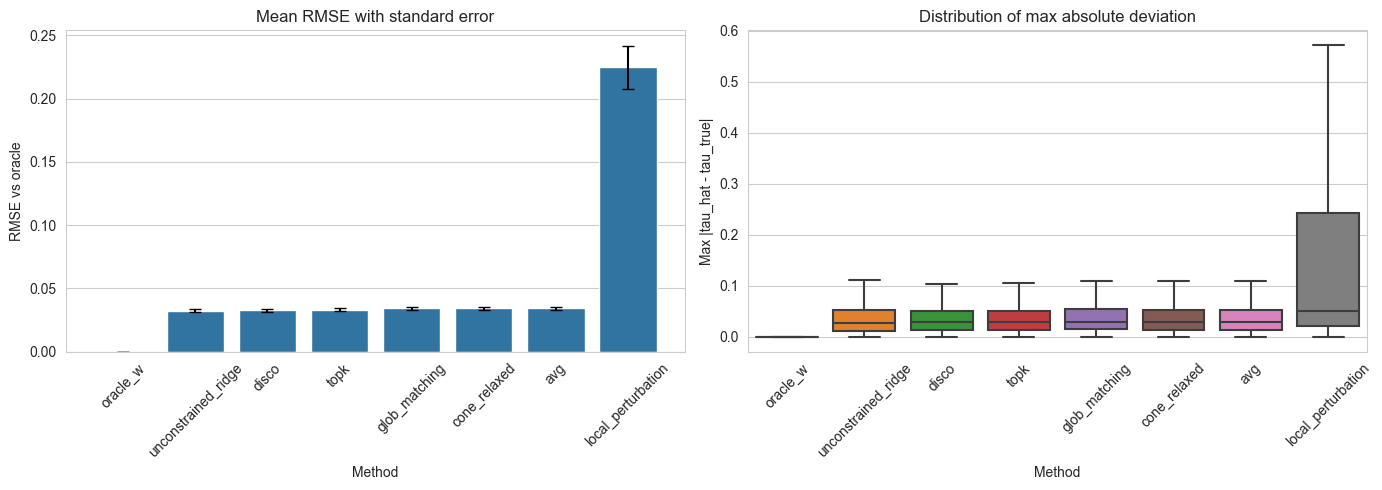

In [13]:
# Visual comparisons
sns.set_style('whitegrid')
order = summary.sort_values('rmse_mean')['method']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bar_data = summary.set_index('method').loc[order].reset_index()
sns.barplot(data=bar_data, x='method', y='rmse_mean', ax=ax, color='C0')
yerr = bar_data['rmse_sem']
ax.errorbar(range(len(bar_data)), bar_data['rmse_mean'], yerr=yerr, fmt='none', c='black', capsize=4)
ax.set_ylabel('RMSE vs oracle')
ax.set_xlabel('Method')
ax.set_title('Mean RMSE with standard error')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
sample_df = results_df[results_df['method'].isin(order)]
sns.boxplot(data=sample_df, x='method', y='max_abs', ax=ax, order=order, showfliers=False)
ax.set_ylabel('Max |tau_hat - tau_true|')
ax.set_xlabel('Method')
ax.set_title('Distribution of max absolute deviation')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()


In [14]:
# Optional: relative performance vs DISCO
pivot_metrics = results_df.pivot_table(
    index=['intervention', 'query_index'],
    columns='method',
    values='rmse'
)
if 'disco' in pivot_metrics.columns:
    diff_vs_disco = pivot_metrics.subtract(pivot_metrics['disco'], axis=0)
    rel_summary = diff_vs_disco.mean().sort_values()
    rel_summary
else:
    print('DISCO results missing from pivot table; skipping relative summary.')


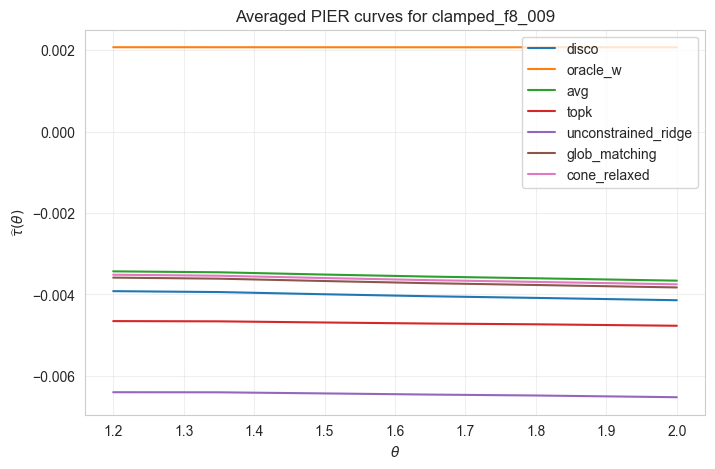

In [15]:
chosen_intervention = interventions[9].name if interventions else None
if chosen_intervention and curve_bank:
    import numpy as np
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 5))
    for method, curves in curve_bank[chosen_intervention].items():
        if method == 'local_perturbation':
            continue
        curve_array = np.stack(curves)
        mean_curve = curve_array.mean(axis=0)
        sem_curve = curve_array.std(axis=0) / np.sqrt(curve_array.shape[0])
        plt.plot(theta_vec, mean_curve, label=method)
        # plt.fill_between(theta_vec, mean_curve - sem_curve, mean_curve + sem_curve, alpha=0.2)
    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$\widehat{\tau}(\theta)$')
    plt.title(f'Averaged PIER curves for {chosen_intervention}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No intervention curves available.')
